In [4]:
%gui osx

There is a problem with your code:
SyntaxError: invalid syntax (<py5bot>, line 1)
    %gui osx
    ^


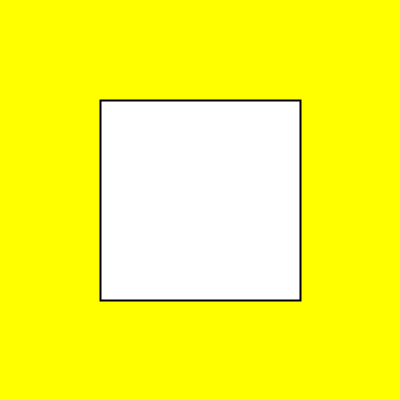

In [3]:


size(200, 200)
background(255, 255, 0)
rect(50, 50, 100, 100)


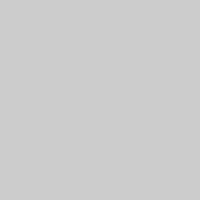

In [5]:
"""Spinning torus wireframe — animated. trimesh + matplotlib."""
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

MESH = trimesh.creation.torus(major_radius=1.0, minor_radius=0.42)

def _ry(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])

def _rx(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])

def draw(t):
    R = _rx(0.9) @ _ry(2 * np.pi * t)
    v = MESH.vertices @ R.T

    edges = MESH.edges_unique
    segs = v[:, :2][edges]                      # (n_edges, 2, 2)
    depth = v[:, 2][edges].mean(axis=1)
    shade = (depth - depth.min()) / (np.ptp(depth) + 1e-9)

    fig, ax = plt.subplots(figsize=(5.12, 5.12), dpi=100)
    fig.patch.set_facecolor("#05060f")
    ax.set_facecolor("#05060f")
    ax.add_collection(LineCollection(
        segs, colors=plt.cm.cool(shade),
        linewidths=0.4 + 1.2 * shade, alpha=0.9))

    ax.set_xlim(-1.7, 1.7), ax.set_ylim(-1.7, 1.7)
    ax.set_aspect("equal"), ax.axis("off")
    fig.subplots_adjust(0, 0, 1, 1)
    return fig